**Script: General analysis on the mux0001_b5b7 output, focusing on the regional ocean output profiles**
- Author: Muxin Hu (muxin.hu@mpimet.mpg.de)
- Date created: 04/01/2026
- Lastest modified: 04/01/2026

**Paths**
- the package is downloaded and installed in the directory: `/home/m/m301254/Download/pyicon`

In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import pyicon as pyic
import cartopy.crs as ccrs
# from netCDF4 import Dataset
import sys

import cartopy.feature as cfeature
from matplotlib import cm

----Start loading pyicon.
Loading default parameters from /home/m/m301254/Download/pyicon/pyicon/params_default.json.
----Start loading pyicon.
----Pyicon was loaded successfully.
----Pyicon was loaded successfully.


# Paths: Data/grids/ckdtree/fx
- notice different for the default and experiment (with different `c_k`)

In [ ]:
# data, grid paths
run_def='mux0001_b5b7'
run_ep1='mux0001_b5b7_c_k-03'
run_ep2='mux0001_b5b7_c_k-10'

gname_oce = 'r2b7_oce_r0005'
gname_atm = 'r2b5_atm_r0030'
lev_oce = 'L72'

# data paths
path_data_def = f'/work/mh0033/m301254/proj_surfwave/icon-2025-08-06-XPP/icon-mpim/experiments/{run_def}/outdata/'
path_data_ep1 = f'/work/mh0033/m301254/proj_surfwave/icon-2025-08-06-XPP/icon-mpim/experiments/{run_ep1}/outdata/'

# grid paths
path_grid_oce = f'/home/m/m301254/pyicon_data/grids/{gname_oce}/'
path_grid_atm = f'/home/m/m301254/pyicon_data/grids/{gname_atm}/'

# tgrid and ckdtree paths for both oce and atm
fpath_tgrid = {}
fpath_ckdtree = {}

fpath_tgrid["oce"] = (f'{path_grid_oce}{gname_oce}_tgrid.nc')
fpath_tgrid["atm"] = (f'{path_grid_atm}{gname_atm}_tgrid.nc')

fpath_ckdtree["oce"] = (f'{path_grid_oce}ckdtree/rectgrids/r2b7_oce_r0005_res0.30_180W-180E_90S-90N.nc')
fpath_ckdtree["atm"] = (f'{path_grid_atm}ckdtree/rectgrids/r2b5_atm_r0030_res0.30_180W-180E_90S-90N.nc')


# 3D dataset, pre-processed `to`, `so` and `rhopot` from `oce_def`
- Notice difference for the default and experiment
- Contains the 3d surface field of to, so, rhopot

In [3]:
# processed data paths
path_prodata_def = f'/work/mh0033/m301254/proj_surfwave/processed_data/{run_def}/'
path_prodata_ep1 = f'/work/mh0033/m301254/proj_surfwave/processed_data/{run_ep1}/'
path_prodata_ep2 = f'/work/mh0033/m301254/proj_surfwave/processed_data/{run_ep2}/'

## Climatological field of to, so, rhopot

In [4]:
# read the preprocessed data
to_clim_def = xr.open_dataset(f'{path_prodata_def}{run_def}_oce_def_to_1330-1345_mean.nc')['to']
to_clim_ck3 = xr.open_dataset(f'{path_prodata_ep1}{run_ep1}_oce_def_to_1330-1345_mean.nc')['to']
to_clim_ck10 = xr.open_dataset(f'{path_prodata_ep2}{run_ep2}_oce_def_to_1330-1345_mean.nc')['to']

so_clim_def = xr.open_dataset(f'{path_prodata_def}{run_def}_oce_def_so_1330-1345_mean.nc')['so']
so_clim_ck3 = xr.open_dataset(f'{path_prodata_ep1}{run_ep1}_oce_def_so_1330-1345_mean.nc')['so']
so_clim_ck10 = xr.open_dataset(f'{path_prodata_ep2}{run_ep2}_oce_def_so_1330-1345_mean.nc')['so']

rhopot_clim_def = xr.open_dataset(f'{path_prodata_def}{run_def}_oce_def_rhopot_1330-1345_mean.nc')['rhopot']
rhopot_clim_ck3 = xr.open_dataset(f'{path_prodata_ep1}{run_ep1}_oce_def_rhopot_1330-1345_mean.nc')['rhopot']
rhopot_clim_ck10 = xr.open_dataset(f'{path_prodata_ep2}{run_ep2}_oce_def_rhopot_1330-1345_mean.nc')['rhopot']

/tmp/ipykernel_1235425/335964228.py:2: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  to_clim_def = xr.open_dataset(f'{path_prodata_def}{run_def}_oce_def_to_1330-1345_mean.nc')['to']
/tmp/ipykernel_1235425/335964228.py:3: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  to_clim_ck3 = xr.open_dataset(f'{path_prodata_ep1}{run_ep1}_oce_def_to_1330-1345_mean.nc')['to']
/tmp/ipykernel_1235425/335964228.py:4: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cft

### Regional mask; 1st try -> using lat and lon limit
- defined as:
    ```
    lon_reg = [-83, -76]
    lat_reg = [-14, -4]
    ```

In [6]:
# find the depth index closest to 1000m
iz = int(to_clim_def['depth_2'].to_index().get_indexer([2000.0], method='nearest')[0])
print(iz)

53


In [ ]:
# Triangulation dataset
ds_tg = xr.open_dataset(fpath_tgrid["oce"])
# regional: smaller Pacific
lon_reg = [-83, -76]
lat_reg = [-14, -4]
ind_reg, Tri_reg = pyic.triangulation(ds_tg, lon_reg=lon_reg, lat_reg=lat_reg)

to_clim_def_reg = to_clim_def.isel(ncells=ind_reg, depth_2=range(0,iz+1))
to_clim_ck3_reg = to_clim_ck3.isel(ncells=ind_reg, depth_2=range(0,iz+1))
to_clim_ck10_reg = to_clim_ck10.isel(ncells=ind_reg, depth_2=range(0,iz+1))

so_clim_def_reg = so_clim_def.isel(ncells=ind_reg, depth_2=range(0,iz+1))
so_clim_ck3_reg = so_clim_ck3.isel(ncells=ind_reg, depth_2=range(0,iz+1))
so_clim_ck10_reg = so_clim_ck10.isel(ncells=ind_reg, depth_2=range(0,iz+1))

rhopot_clim_def_reg = rhopot_clim_def.isel(ncells=ind_reg, depth_2=range(0,iz+1))
rhopot_clim_ck3_reg = rhopot_clim_ck3.isel(ncells=ind_reg, depth_2=range(0,iz+1))
rhopot_clim_ck10_reg = rhopot_clim_ck10.isel(ncells=ind_reg, depth_2=range(0,iz+1))


#### Regional mean profiles

In [8]:
# apply the weight of the cell area to compute the area-weighted average profile
cell_area = ds_tg['cell_area'].rename({'cell': 'ncells'})
cell_area_reg = cell_area.isel(ncells=ind_reg)
area_weights = cell_area_reg / cell_area_reg.sum()

# calculate the area-weighted averaged profiles
to_clim_def_pf = (to_clim_def_reg * area_weights).sum(dim='ncells')
to_clim_ck3_pf = (to_clim_ck3_reg * area_weights).sum(dim='ncells')
to_clim_ck10_pf = (to_clim_ck10_reg * area_weights).sum(dim='ncells')


In [9]:
so_clim_def_pf = (so_clim_def_reg * area_weights).sum(dim='ncells')
so_clim_ck3_pf = (so_clim_ck3_reg * area_weights).sum(dim='ncells')
so_clim_ck10_pf = (so_clim_ck10_reg * area_weights).sum(dim='ncells')

In [10]:
rhopot_clim_def_pf = (rhopot_clim_def_reg * area_weights).sum(dim='ncells')
rhopot_clim_ck3_pf = (rhopot_clim_ck3_reg * area_weights).sum(dim='ncells')
rhopot_clim_ck10_pf = (rhopot_clim_ck10_reg * area_weights).sum(dim='ncells')

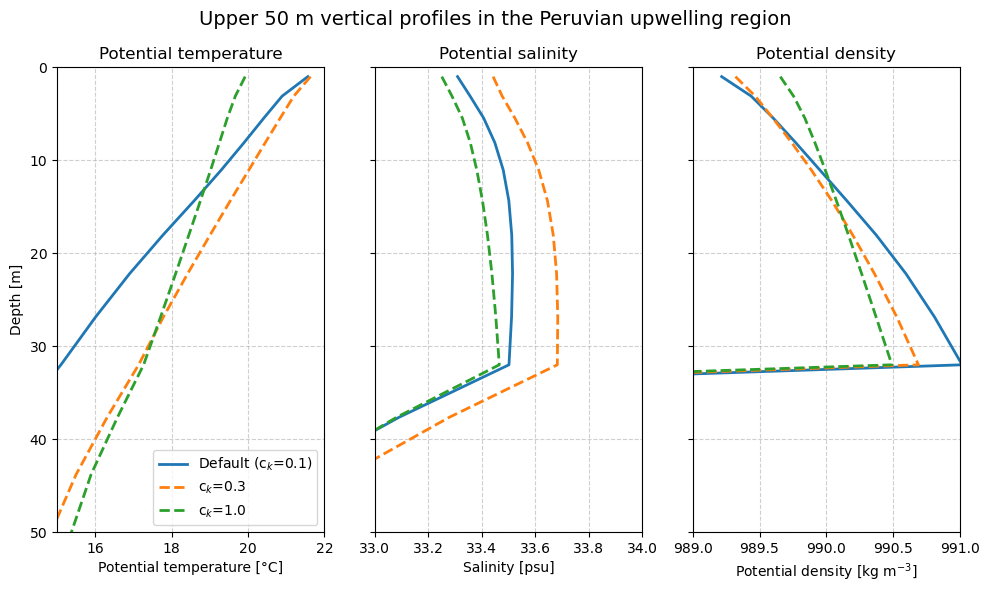

In [39]:
fig, axes = plt.subplots(nrows=1, ncols=3,
                         figsize=(10, 6),
                         sharey=True)

# ======================================================
# 1) Potential temperature
# ======================================================
ax = axes[0]
ax.plot(to_clim_def_pf.squeeze().values, to_clim_def_pf.depth_2.values, 
        label='Default (c$_k$=0.1)', linewidth=2)
ax.plot(to_clim_ck3_pf.squeeze().values, to_clim_ck3_pf.depth_2.values, 
        label='c$_k$=0.3', linewidth=2,linestyle='--')
ax.plot(to_clim_ck10_pf.squeeze().values, to_clim_ck10_pf.depth_2.values,
        label='c$_k$=1.0', linewidth=2, linestyle='--')
ax.set_ylim(50, 0)
ax.set_xlabel('Potential temperature [°C]')
ax.set_title('Potential temperature')
ax.set_xlim(15,22)
ax.grid(True, linestyle='--', alpha=0.6)

# ======================================================
# 2) Potential salinity
# ======================================================
ax = axes[1]
ax.plot(so_clim_def_pf.squeeze().values, so_clim_def_pf.depth_2.values,
        linewidth=2)
ax.plot(so_clim_ck3_pf.squeeze().values, so_clim_ck3_pf.depth_2.values,
        linewidth=2, linestyle='--')
ax.plot(so_clim_ck10_pf.squeeze().values, so_clim_ck10_pf.depth_2.values,
        linewidth=2, linestyle='--')
ax.set_xlabel('Salinity [psu]')
ax.set_title('Potential salinity')
ax.set_xlim(33,34)
ax.grid(True, linestyle='--', alpha=0.6)

# ======================================================
# 3) Potential density
# ======================================================
ax = axes[2]
ax.plot(rhopot_clim_def_pf.squeeze().values, rhopot_clim_def_pf.depth_2.values, 
        linewidth=2)
ax.plot(rhopot_clim_ck3_pf.squeeze().values, rhopot_clim_ck3_pf.depth_2.values,
        linewidth=2, linestyle='--')
ax.plot(rhopot_clim_ck10_pf.squeeze().values, rhopot_clim_ck10_pf.depth_2.values,
        linewidth=2, linestyle='--')
ax.set_xlabel(r'Potential density [kg m$^{-3}$]')
ax.set_title('Potential density')
ax.set_xlim(989, 991)
ax.grid(True, linestyle='--', alpha=0.6)

# ======================================================
# Shared settings
# ======================================================
axes[0].set_ylabel('Depth [m]')
axes[0].legend(loc='best')
fig.suptitle('Upper 50 m vertical profiles in the Peruvian upwelling region', fontsize=14)
fig.tight_layout()
outpath = "/home/m/m301254/project_surfwaves/figs"
outfile = f"{outpath}/basic_regionalmean_profiles_PeruCoast_focus_upper50.png"

fig.savefig(outfile, dpi=150, bbox_inches="tight", facecolor="white")